In [30]:
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
patient=pd.read_csv("patient_cleaned.csv")

In [32]:
le= LabelEncoder()
patient["risk_level"]= le.fit_transform(patient["risk_level"])


In [33]:
patient['smoking'] = patient['smoking'].map({
    'No': 0, 'Former': 1, 'Yes': 2
})

patient['exercise_habit'] = patient['exercise_habit'].map({
    'Light': 0, 'Moderate': 1, 'Heavy': 2
})

patient['alcohol_consumption'] = patient['alcohol_consumption'].map({
    'Occasional': 0, 'Moderate': 1, 'Heavy': 2
})

patient['outcome'] = patient['outcome'].map({
    'Recovered': 0, 'Ongoing': 1, 'Critical': 2
})

patient['stress_level'] = patient['stress_level'].map({
    'Low': 0, 'Medium': 1, 'High': 2
})

patient['cholesterol'] = patient['cholesterol'].map({
    'Normal': 0, 'Borderline': 1, 'High': 2
})

patient['family_history'] = patient['family_history'].map({
    'No': 0, 'Yes': 1
})

patient['diet_quality'] = patient['diet_quality'].map({
    'Poor': 0, 'Average': 1, 'Good': 2
})

In [34]:
patient = pd.get_dummies(patient, columns=['gender', 'blood_type', 'diagnosis']) 

In [35]:
patient.dtypes

patient_id                  object
name                        object
age                          int64
bmi                        float64
bp_systolic                float64
bp_diastolic               float64
heart_rate                 float64
cholesterol                  int64
glucose_level              float64
hba1c                      float64
smoking                      int64
alcohol_consumption          int64
exercise_habit               int64
diet_quality                 int64
stress_level                 int64
family_history               int64
num_medications              int64
prev_hospitalizations        int64
risk_level                   int64
outcome                      int64
admission_date              object
length_of_stay_days          int64
hospital_bill_usd          float64
gender_Female                 bool
gender_Male                   bool
gender_Other                  bool
blood_type_A+                 bool
blood_type_A-                 bool
blood_type_AB+      

In [36]:
patient

,patient_id,name,age,bmi,bp_systolic,bp_diastolic,heart_rate,cholesterol,glucose_level,hba1c,...,blood_type_B+,blood_type_B-,blood_type_O+,blood_type_O-,diagnosis_Asthma,diagnosis_Diabetes,diagnosis_Heart Disease,diagnosis_Hypertension,diagnosis_Obesity,diagnosis_Unknown
0,P1123,Rohit Shah,35,29.6,110.0,82.0,59.0,0,133.0,5.9,...,False,False,False,False,False,False,False,False,False,True
1,P1442,Sneha Jones,21,28.0,145.0,101.0,72.0,1,93.4,5.6,...,False,False,False,False,False,False,False,True,False,False
2,P0352,Hassan Williams,43,32.6,153.0,78.0,79.0,1,147.1,7.8,...,False,False,True,False,False,False,False,False,False,True
3,P0353,Harper Thomas,33,24.6,165.0,61.0,58.0,2,61.4,3.8,...,False,False,True,False,False,False,False,False,True,False
4,P0579,Daniel Jones,51,28.0,109.0,100.0,101.0,0,60.5,6.1,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,P1131,Arjun Wilson,33,28.1,167.0,87.0,60.0,0,74.1,7.4,...,False,False,False,False,False,False,False,True,False,False
1496,P1295,Harper Wilson,56,22.0,95.0,112.0,56.0,2,46.0,6.6,...,False,False,False,False,False,False,False,True,False,False
1497,P0861,Ahmed Anderson,40,30.0,148.0,109.0,99.0,0,143.9,4.4,...,False,False,True,False,False,False,True,False,False,False
1498,P1460,Rohit White,57,23.6,181.0,58.0,56.0,0,90.5,5.2,...,False,False,True,False,False,False,False,False,False,True


In [37]:
patient.dtypes

patient_id                  object
name                        object
age                          int64
bmi                        float64
bp_systolic                float64
bp_diastolic               float64
heart_rate                 float64
cholesterol                  int64
glucose_level              float64
hba1c                      float64
smoking                      int64
alcohol_consumption          int64
exercise_habit               int64
diet_quality                 int64
stress_level                 int64
family_history               int64
num_medications              int64
prev_hospitalizations        int64
risk_level                   int64
outcome                      int64
admission_date              object
length_of_stay_days          int64
hospital_bill_usd          float64
gender_Female                 bool
gender_Male                   bool
gender_Other                  bool
blood_type_A+                 bool
blood_type_A-                 bool
blood_type_AB+      

In [38]:
patient = patient.drop(columns=['patient_id', 'name', 'admission_date'])

In [39]:
patient = patient.astype({col: int for col in patient.select_dtypes(bool).columns})

In [40]:
patient.columns

Index(['age', 'bmi', 'bp_systolic', 'bp_diastolic', 'heart_rate',
       'cholesterol', 'glucose_level', 'hba1c', 'smoking',
       'alcohol_consumption', 'exercise_habit', 'diet_quality', 'stress_level',
       'family_history', 'num_medications', 'prev_hospitalizations',
       'risk_level', 'outcome', 'length_of_stay_days', 'hospital_bill_usd',
       'gender_Female', 'gender_Male', 'gender_Other', 'blood_type_A+',
       'blood_type_A-', 'blood_type_AB+', 'blood_type_AB-', 'blood_type_B+',
       'blood_type_B-', 'blood_type_O+', 'blood_type_O-', 'diagnosis_Asthma',
       'diagnosis_Diabetes', 'diagnosis_Heart Disease',
       'diagnosis_Hypertension', 'diagnosis_Obesity', 'diagnosis_Unknown'],
      dtype='object')

In [41]:
x=patient[['age', 'bmi', 'bp_systolic', 'bp_diastolic', 'heart_rate',
       'cholesterol', 'glucose_level', 'hba1c', 'smoking',
       'alcohol_consumption', 'exercise_habit', 'diet_quality', 'stress_level',
       'family_history', 'num_medications', 'prev_hospitalizations',
        'outcome', 'length_of_stay_days', 'hospital_bill_usd',
       'gender_Female', 'gender_Male', 'gender_Other', 'blood_type_A+',
       'blood_type_A-', 'blood_type_AB+', 'blood_type_AB-', 'blood_type_B+',
       'blood_type_B-', 'blood_type_O+', 'blood_type_O-', 'diagnosis_Asthma',
       'diagnosis_Diabetes', 'diagnosis_Heart Disease',
       'diagnosis_Hypertension', 'diagnosis_Obesity', 'diagnosis_Unknown']]
y=patient['risk_level']

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [43]:
model=RandomForestClassifier(n_estimators=200,max_depth=5,random_state=42,class_weight="balanced")
model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=200,
                       random_state=42)

In [44]:
y_pred=model.predict(x_test)

In [45]:
print("Accuracy : " , accuracy_score(y_test,y_pred))

Accuracy :  0.8766666666666667


In [46]:
print("Train Accuracy:", accuracy_score(y_train, model.predict(x_train)))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.9025
Test Accuracy: 0.8766666666666667


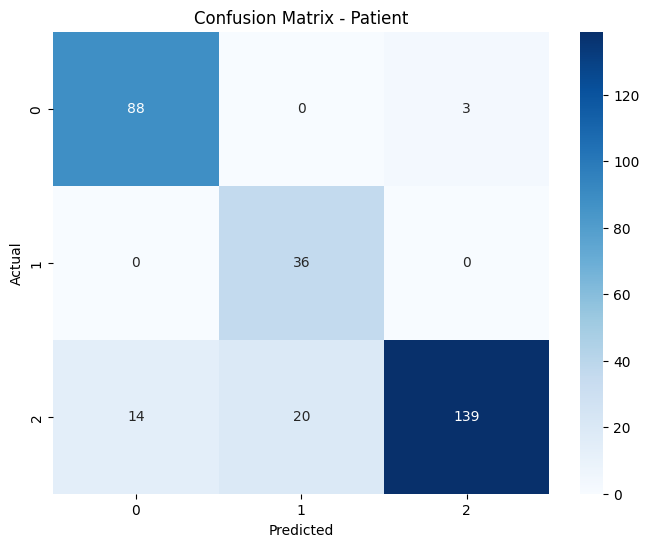

              precision    recall  f1-score   support

           0       0.86      0.97      0.91        91
           1       0.64      1.00      0.78        36
           2       0.98      0.80      0.88       173

    accuracy                           0.88       300
   macro avg       0.83      0.92      0.86       300
weighted avg       0.90      0.88      0.88       300



In [47]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Patient')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

In [65]:
importances=model.feature_importances_

/var/folders/6m/qm4yytdd1ql5xd4tkcvf2d880000gn/T/ipykernel_889/953656656.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(15), palette='viridis')


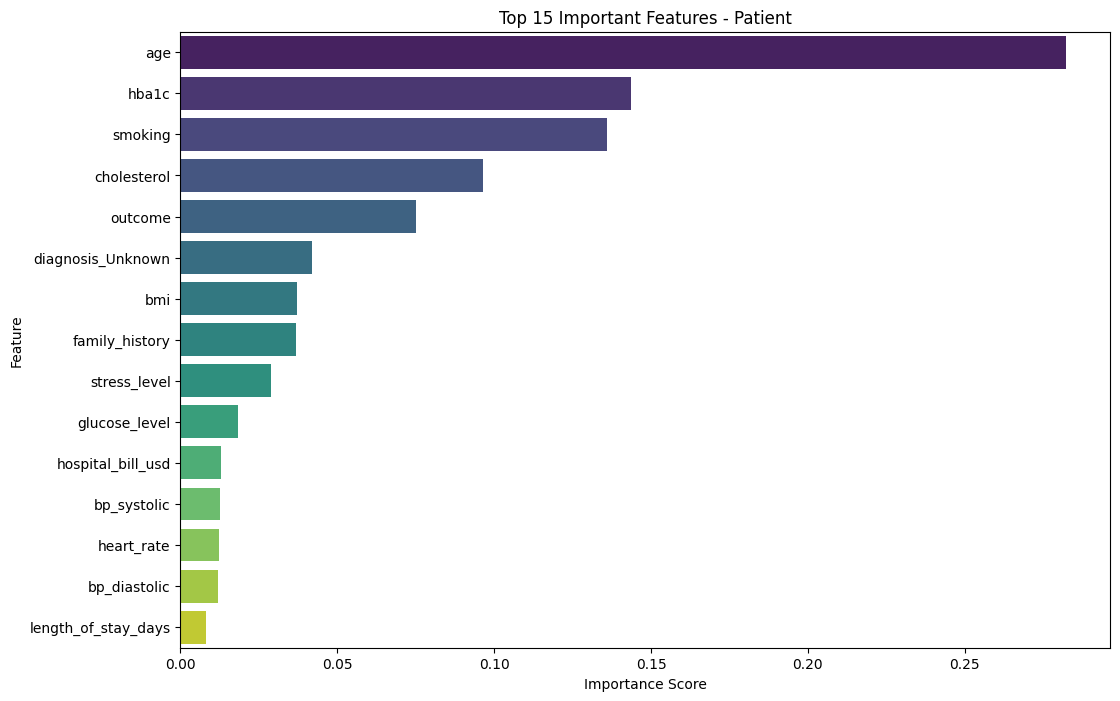

In [69]:
# Create dataframe
feature_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importances
})

# Sort by importance
feature_df = feature_df.sort_values('Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(12,8))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(15), palette='viridis')
plt.title('Top 15 Important Features - Patient')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

In [71]:
pickle.dump(model,open("PATIENT_model.pkl","wb"))
print("Model Saved")

Model Saved
